# 목적별 과목 설계 제안 — 과목 설계 지표와 이탈·성취·조기 탐지 (`07_Course_Design_Indicators`)

```
03_Final_Model_Tiers → 04_Second_Checkpoint → 05_Intervention_Guide → 06_Sensitivity_Ambiguous → [07_Course_Design_Indicators]
```

## 목적

01–06은 **"이 과목 안에서 누가 떠날까"**를 다뤘다. 이 노트북은 반대 방향으로 **"어떤 과목 설계가 이탈·성취·조기 탐지·운영에 유리한가"**를 본다.
기관이 과목을 설계·개편할 때 **목적에 따라 다른 제안**을 할 수 있도록, 과목×학기 단위 설계 지표와 결과 지표의 관계를 정량으로 정리한다.

| 목적 | 결과 지표 | 질문 |
|---|---|---|
| A. 재학 유지 | 25일 전 이탈 비율, 25일 이후 이탈률 | 어떤 설계에서 학생이 덜 떠나는가 |
| B. 학업 성취 | 완주자 합격률(Pass·Distinction) | 끝까지 남은 학생이 더 많이 합격하는가 |
| C. 조기 탐지 | 학기별 예측 성능(ROC-AUC, PR-AUC 배수) | 25일 시점에 위험 학생을 가려낼 신호가 생기는가 |
| D. 관리자 운영 | 관리자 명단 비율(1차+2차) | 관리자가 대응할 명단이 얼마나 커지는가 |
| E. 재학습 안정성 | 학기 간 설계 변화와 성능 변화 | 모델을 계속 쓸 수 있는가 |

## 원칙과 한계 (먼저 읽기)

- **표본이 매우 작다**: 과목 7개, 과목×학기 22개다. 같은 과목의 학기들은 서로 독립이 아니므로 실질 표본은 7에 가깝다.
- **설계가 다른 요인과 묶여 있다**: 분야(사회과학 AAA·BBB·GGG / STEM CCC·DDD·EEE·FFF, Kuzilek et al., 2017 Table 1), 학생 구성(GGG 학점 중앙값 30), 개강 시기(B학기 과목 기간이 약 240일, J학기 약 268일).
- 그래서 한 가지 상관만 믿지 않고, **네 가지 수준에서 방향이 일치하는지** 본다: ① 과목×학기 전체, ② 과목 내(과목 평균 제거), ③ 과목·학기 고정효과 잔차, ④ 과목 평균(n=7). 여기에 **같은 과목에서 설계만 바뀐 학기**를 다른 과목의 같은 기간 변화와 비교(이중차분)한다.
- 결과는 **인과 효과가 아니라 설계 가설의 근거 강도**다. 제안마다 근거 강도(강·중·약·근거 없음)를 붙인다.
- 예측 성능은 개발 학기는 교차검증 OOF, 2014J는 holdout 예측으로 계산했다(순위 지표만 사용).

## 1. 환경 설정과 데이터

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import average_precision_score, roc_auc_score

INK, INK_2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.facecolor': SURFACE,
                     'axes.facecolor': SURFACE, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': GRID, 'text.color': INK_2, 'axes.titlecolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'legend.frameon': False})
pd.set_option('display.width', 240)
pd.set_option('display.max_columns', 60)
MODULE_COLORS = {'AAA': '#4C72B0', 'BBB': '#DD8452', 'CCC': '#55A868', 'DDD': '#C44E52', 'EEE': '#8172B3', 'FFF': '#937860', 'GGG': '#DA8BC3'}
DOMAIN = {'AAA': '사회과학', 'BBB': '사회과학', 'GGG': '사회과학', 'CCC': 'STEM', 'DDD': 'STEM', 'EEE': 'STEM', 'FFF': 'STEM'}


def show(frame, formats=None):
    view = frame.copy()
    for col, f in (formats or {}).items():
        if col in view.columns:
            view[col] = view[col].map(lambda v, f=f: f.format(v) if pd.notna(v) else '')
    display(view)


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()
CSV_DIR = PROJECT_ROOT / 'CSV_files'
DATA_DIR, MODEL_DIR = CSV_DIR / '통합 버전', CSV_DIR / '모델링'
MP = ['code_module', 'code_presentation']

courses = pd.read_csv(CSV_DIR / 'courses.csv')
assessments = pd.read_csv(CSV_DIR / 'assessments.csv')
vle_sites = pd.read_csv(CSV_DIR / 'vle.csv')
all_cohorts = pd.read_csv(DATA_DIR / 'landmark25_all_cohorts.csv')
oof = pd.read_csv(MODEL_DIR / 'dev_oof_predictions_n25.csv')
hold = pd.read_csv(MODEL_DIR / 'final_holdout_tiers_n25.csv')
cp_students = pd.read_csv(MODEL_DIR / 'second_checkpoint_students_n25.csv')
assert len(all_cohorts) == 32_593 and len(courses) == 22
print('과목×학기:', len(courses), '/ 전체 등록:', f'{len(all_cohorts):,}', '/ 모델 대상:', f"{(all_cohorts['cohort_status_25'] == 'model_eligible').sum():,}")

과목×학기: 22 / 전체 등록: 32,593 / 모델 대상: 27,661


## 2. 과목 설계 지표 (과목×학기 22개)

**왜 보는가**: 기관이 **직접 바꿀 수 있는 설계 요소**만 모은다. 학생 구성(학점 등)은 설계가 아니므로 참고 지표로 둔다.

| 지표 | 정의 | 원본 |
|---|---|---|
| `과목 기간` | 개강부터 종강까지 일수 | `courses.csv` |
| `TMA 수`, `CMA 수`, `평가 수` | 튜터 채점 과제·컴퓨터 채점 평가 개수 (Exam 제외) | `assessments.csv` |
| `평가 밀도` | 100일당 TMA·CMA 수 | |
| `CMA 가중치`, `시험 가중치` | 평가 유형별 가중치 합 | |
| `첫 평가일`, `첫 평가 가중치` | 첫 TMA·CMA 마감일과 가중치 | |
| `25일 내 평가 수`, `60일 내 평가 수` | 해당 기간 안에 마감되는 TMA·CMA 수 | |
| `평가 간격 중앙값` | 연속 마감일 사이 일수의 중앙값 | |
| `학습 자료 수`, `자료 유형 수`, `퀴즈 비중`, `포럼 비중` | VLE 자료 개수·유형 | `vle.csv` |
| `25일 클릭 중앙값` | 모델 대상 학생의 25일 클릭 중앙값 (초기 참여 설계의 결과) | 통합 정본 |
| `학점 중앙값` | 학생 수강 학점 중앙값 (**설계 아님, 참고**) | 통합 정본 |

In [2]:
ta = assessments[assessments['assessment_type'] != 'Exam']
d = courses.set_index(MP).rename(columns={'module_presentation_length': '과목 기간'})
d['TMA 수'] = assessments[assessments['assessment_type'] == 'TMA'].groupby(MP).size()
d['CMA 수'] = assessments[assessments['assessment_type'] == 'CMA'].groupby(MP).size()
d = d.fillna({'TMA 수': 0, 'CMA 수': 0})
d['평가 수'] = d['TMA 수'] + d['CMA 수']
d['평가 밀도'] = d['평가 수'] / d['과목 기간'] * 100
d['CMA 가중치'] = assessments[assessments['assessment_type'] == 'CMA'].groupby(MP)['weight'].sum()
d['시험 가중치'] = assessments[assessments['assessment_type'] == 'Exam'].groupby(MP)['weight'].sum()
d = d.fillna({'CMA 가중치': 0})
first = ta.sort_values(['date', 'id_assessment']).groupby(MP).first()
d['첫 평가일'] = first['date']
d['첫 평가 가중치'] = first['weight']
d['25일 내 평가 수'] = ta[ta['date'] <= 25].groupby(MP).size()
d['60일 내 평가 수'] = ta[ta['date'] <= 60].groupby(MP).size()
d = d.fillna({'25일 내 평가 수': 0, '60일 내 평가 수': 0})
d['평가 간격 중앙값'] = ta.dropna(subset=['date']).sort_values('date').groupby(MP)['date'].apply(lambda s: s.diff().median())
d['학습 자료 수'] = vle_sites.groupby(MP).size()
d['자료 유형 수'] = vle_sites.groupby(MP)['activity_type'].nunique()
d['퀴즈 비중'] = vle_sites.assign(v=vle_sites['activity_type'].isin(['quiz', 'externalquiz'])).groupby(MP)['v'].mean()
d['포럼 비중'] = vle_sites.assign(v=vle_sites['activity_type'].eq('forumng')).groupby(MP)['v'].mean()
eligible = all_cohorts[all_cohorts['cohort_status_25'] == 'model_eligible']
d['25일 클릭 중앙값'] = eligible.groupby(MP)['total_click_25'].median()
d['학점 중앙값'] = eligible.groupby(MP)['studied_credits'].median()
d = d.reset_index()
d.insert(2, '분야', d['code_module'].map(DOMAIN))
d.insert(3, '개강 시기', d['code_presentation'].str[-1])
assert len(d) == 22 and d['첫 평가일'].notna().all()
show(d.set_index(MP), {'평가 밀도': '{:.2f}', '퀴즈 비중': '{:.1%}', '포럼 비중': '{:.1%}', '평가 간격 중앙값': '{:.1f}', '첫 평가 가중치': '{:.1f}',
                        **{c: '{:.0f}' for c in ['TMA 수', 'CMA 수', '평가 수', 'CMA 가중치', '시험 가중치', '첫 평가일', '25일 내 평가 수', '60일 내 평가 수', '학습 자료 수', '25일 클릭 중앙값', '학점 중앙값']}})

분야 개강 시기  과목 기간 TMA 수 CMA 수 평가 수 평가 밀도 CMA 가중치 시험 가중치 첫 평가일 첫 평가 가중치 25일 내 평가 수 60일 내 평가 수 평가 간격 중앙값 학습 자료 수  자료 유형 수 퀴즈 비중 포럼 비중 25일 클릭 중앙값 학점 중앙값
code_module code_presentation                                                                                                                                                       
AAA         2013J              사회과학     J    268     5     0    5  1.87       0    100    19     10.0          1          2      49.0     211        9  0.0%  7.1%        282     60
            2014J              사회과학     J    269     5     0    5  1.86       0    100    19     10.0          1          2      49.0     202        9  0.0%  3.0%        244     60
BBB         2013J              사회과학     J    268     6     5   11  4.10       5    100    19      5.0          1          3      17.5     321       10  1.6%  5.9%         78     60
            2014J              사회과학     J    262     5     0    5  1.91       0    100    19      0.0          1          2      45.5     207       10  1.9%  1.4%         90     60
            2013B              사회과학     B    240     6     5   11  4.58       5    100    19      5.0          1          3      17.5     315       10  1.6%  5.4%        119     60
            2014B              사회과학     B    234     6     5   11  4.70       5    100    12      5.0          1          3      17.5     311       10  1.6%  5.5%         73     60
CCC         2014J              STEM     J    269     4     4    8  2.97      25    200    18      2.0          1          2      35.0     223        9  7.2%  4.0%        197     60
            2014B              STEM     B    241     4     4    8  3.32      25    200    18      2.0          1          2      35.0     196        9  8.2%  4.6%        194     60
DDD         2013J              STEM     J    261     6     0    6  2.30       0    100    25     10.0          1          2      35.0     462       10  1.5%  3.5%        157     60
            2014J              STEM     J    262     6     0    6  2.29       0    100    20      5.0          1          2      35.0     365       10  1.4%  3.6%        128     60
            2013B              STEM     B    240     6     7   13  5.42      25    100    23      2.0          2          4      12.5     428       11  1.6%  2.6%        197     60
            2014B              STEM     B    241     6     0    6  2.49       0    100    25     10.0          1          2      42.0     453       10  1.5%  2.9%        161     60
EEE         2013J              STEM     J    268     4     0    4  1.49       0    100    33     16.0          0          1      35.0     112       11  1.8%  4.5%        283     60
            2014J              STEM     J    269     4     0    4  1.49       0    100    33     16.0          0          1      35.0     115       11  1.7%  4.3%        271     60
            2014B              STEM     B    241     4     0    4  1.66       0    100    33     16.0          0          1      35.0     109       11  1.8%  4.6%        240     60
FFF         2013J              STEM     J    268     5     7   12  4.48       0    100    19     12.5          1          2       0.0     529       16  2.1%  1.3%        362     60
            2014J              STEM     J    269     5     7   12  4.46       0    100    24     12.5          1          2       0.0     452       16  2.4%  1.5%        386     60
            2013B              STEM     B    240     5     7   12  5.00       0    100    19     12.5          1          2       0.0     508       14  2.2%  1.0%        389     60
            2014B              STEM     B    241     5     7   12  4.98       0    100    24     12.5          1          2       0.0     478       15  2.3%  1.3%        334     60
GGG         2013J              사회과학     J    261     3     6    9  3.45       0    100    61      0.0          0          0       0.0     137        7  6.6%  1.5%         24     30
            2014J              사회과학     J    269   

**해석 — 과목마다 설계가 크게 다르고, 같은 과목에서도 학기마다 바뀐다**

| 지표 | 범위 | 특징 |
|---|---|---|
| 평가 수(TMA+CMA) | 4개(EEE) ~ 13개(DDD 2013B) | CMA는 FFF 7, GGG 6, BBB 5, CCC 4개. AAA·EEE는 없음 |
| 첫 평가일 | 12일(BBB 2014B) ~ 61일(GGG) | EEE 33일, 나머지는 18–25일 |
| 첫 평가 가중치 | 0(BBB 2014J, GGG) ~ 16(EEE) | 가중치 0이면 점수가 성적에 반영되지 않는 연습 평가 |
| 학습 자료 수 | 106개(GGG 2014J) ~ 529개(FFF 2013J) | |
| 25일 클릭 중앙값 | 24회(GGG 2013J) ~ 389회(FFF 2013B) | |

- **같은 과목 안에서 설계가 바뀐 학기**가 있다: BBB 2014J(평가 11 → 5개, 첫 평가 가중치 5 → 0), DDD 2013B(CMA 7개 추가), DDD 2014J(첫 평가 25 → 20일), FFF 2014B·2014J(첫 평가 19 → 24일), BBB 2014B(첫 평가 19 → 12일). 5절에서 이 변화들을 사례로 쓴다.
- **설계가 아닌 요인도 과목에 묶여 있다**: 과목 기간은 개강 시기와 거의 같이 움직이고(B학기 234–241일, J학기 261–269일), GGG는 학점 중앙값이 30으로 다른 과목(60)의 절반이다. CCC만 시험 가중치가 200(시험 2회)이다.

## 3. 목적별 결과 지표

| 목적 | 지표 | 정의 |
|---|---|---|
| A. 재학 유지 | `25일 전 이탈 비율` | 전체 등록 중 25일까지 취소한 비율 (01–06 모델 범위 밖) |
| | `25일 이후 이탈률` | 25일 재학생 중 이후 `Withdrawn` 비율 (모델 타깃) |
| | `전체 Withdrawn 비율` | 전체 등록 중 최종 `Withdrawn` |
| B. 학업 성취 | `완주자 합격률` | `Withdrawn`이 아닌 학생 중 Pass·Distinction |
| C. 조기 탐지 | `ROC-AUC`, `PR-AUC 배수` | 학기별 최종 XGBoost 예측 성능. PR-AUC 배수 = PR-AUC ÷ 이탈률 |
| D. 관리자 운영 | `관리자 명단 비율`, `명단 포착률` | 1차(고위험·주의)+2차 승격 명단 비율과 그 명단이 잡은 이탈자 비율 |

In [3]:
o = pd.DataFrame(index=pd.MultiIndex.from_frame(d[MP]))
g_all = all_cohorts.groupby(MP)
o['등록 학생'] = g_all.size()
o['25일 전 이탈 비율'] = g_all['cohort_status_25'].apply(lambda s: (s == 'excluded_early_leaver').mean())
o['25일 이후 이탈률'] = eligible.groupby(MP)['target_churn_after_25'].mean()
o['전체 Withdrawn 비율'] = g_all['final_result'].apply(lambda s: (s == 'Withdrawn').mean())
completers = all_cohorts[all_cohorts['final_result'] != 'Withdrawn']
o['완주자 합격률'] = completers.groupby(MP)['final_result'].apply(lambda s: s.isin(['Pass', 'Distinction']).mean())

pred = pd.concat([oof.rename(columns={'oof_XGBoost': 'p'})[MP + ['target_churn_after_25', 'p']],
                  hold.rename(columns={'pred_proba': 'p'})[MP + ['target_churn_after_25', 'p']]], ignore_index=True)
pg = pred.groupby(MP)
o['ROC-AUC'] = pg.apply(lambda s: roc_auc_score(s['target_churn_after_25'], s['p']))
o['PR-AUC 배수'] = pg.apply(lambda s: average_precision_score(s['target_churn_after_25'], s['p'])) / o['25일 이후 이탈률']
staff = cp_students.assign(명단=cp_students['manager_status'] != '명단 외')
cg = staff.groupby(MP)
o['관리자 명단 비율'] = cg['명단'].mean()
o['명단 포착률'] = cg.apply(lambda s: (s['명단'] & (s['target_churn_after_25'] == 1)).sum() / (s['target_churn_after_25'] == 1).sum())
assert o.notna().all().all()
T = d.merge(o.reset_index(), on=MP, validate='one_to_one')
show(o, {'등록 학생': '{:,}', 'ROC-AUC': '{:.3f}', 'PR-AUC 배수': '{:.2f}', **{c: '{:.1%}' for c in ['25일 전 이탈 비율', '25일 이후 이탈률', '전체 Withdrawn 비율', '완주자 합격률', '관리자 명단 비율', '명단 포착률']}})
term_mean = T.groupby('개강 시기')[['과목 기간', '25일 전 이탈 비율', '25일 이후 이탈률', '완주자 합격률']].mean()
print('개강 시기별 평균 (설계가 아닌 학기 효과 확인용)')
show(term_mean, {'과목 기간': '{:.0f}', '25일 전 이탈 비율': '{:.1%}', '25일 이후 이탈률': '{:.1%}', '완주자 합격률': '{:.1%}'})

등록 학생 25일 전 이탈 비율 25일 이후 이탈률 전체 Withdrawn 비율 완주자 합격률 ROC-AUC PR-AUC 배수 관리자 명단 비율 명단 포착률
code_module code_presentation                                                                                         
AAA         2013J                383        3.1%      13.0%           15.7%   86.1%   0.664      2.23     34.6%  62.5%
            2014J                365        4.7%      14.1%           18.1%   84.6%   0.637      1.46     32.8%  46.9%
BBB         2013J              2,237       17.9%      13.4%           28.8%   67.3%   0.656      1.87     27.4%  49.2%
            2014J              2,292       21.9%      13.2%           32.7%   74.7%   0.586      1.28     45.7%  56.0%
            2013B              1,767        9.8%      20.8%           28.6%   63.6%   0.723      1.93     41.6%  68.4%
            2014B              1,613       20.5%      12.4%           30.4%   64.7%   0.612      1.44     33.9%  54.7%
CCC         2014J              2,498       18.5%      29.2%           43.1%   71.4%   0.710      1.79     52.9%  74.2%
            2014B              1,936       21.5%      31.7%           46.4%   63.9%   0.715      1.65     75.9%  91.9%
DDD         2013J              1,938       14.8%      24.1%           35.1%   66.0%   0.746      2.01     52.1%  81.1%
            2014J              1,803       18.7%      20.3%           35.9%   68.5%   0.704      2.00     48.7%  70.7%
            2013B              1,303        9.1%      26.4%           33.2%   58.6%   0.736      1.80     77.4%  92.3%
            2014B              1,228       15.7%      28.7%           39.9%   64.9%   0.717      1.72     56.2%  78.0%
EEE         2013J              1,052       11.7%      12.9%           23.1%   75.3%   0.668      2.15     18.3%  41.2%
            2014J              1,188       14.0%      13.4%           25.8%   77.6%   0.697      2.20     18.3%  46.3%
            2014B                694       12.4%      14.3%           24.9%   68.5%   0.598      1.38     28.0%  46.0%
FFF         2013J              2,283       13.0%      19.2%           29.6%   68.1%   0.662      1.82     37.8%  60.9%
            2014J              2,365       21.2%      17.9%           36.2%   74.0%   0.712      2.07     36.9%  65.7%
            2013B              1,614        6.8%      20.0%           25.5%   65.0%   0.722      2.10     38.4%  65.8%
            2014B              1,500       13.0%      20.3%           30.8%   63.0%   0.668      1.59     40.3%  61.0%
GGG         2013J                952        2.9%       4.0%            6.9%   66.8%   0.534      1.15      6.9%  10.8%
            2014J                749        4.3%      12.9%           16.8%   71.3%   0.627      1.52      9.8%  22.8%
            2014B                833        4.2%       8.1%           12.0%   65.2%   0.553      1.36     11.0%  16.9%

개강 시기별 평균 (설계가 아닌 학기 효과 확인용)


,과목 기간,25일 전 이탈 비율,25일 이후 이탈률,완주자 합격률
개강 시기,,,,
B,240,12.5%,20.3%,64.2%
J,266,12.8%,16.0%,73.2%


**해석 — 결과 지표도 과목×학기마다 크게 다르다**

| 목적 | 지표 | 최저 | 최고 |
|---|---|---|---|
| A. 재학 유지 | 25일 이후 이탈률 | 4.0% (GGG 2013J) | 31.7% (CCC 2014B) |
| | 25일 전 이탈 비율 | 2.9% (GGG 2013J) | 21.9% (BBB 2014J) |
| B. 학업 성취 | 완주자 합격률 | 58.6% (DDD 2013B) | 86.1% (AAA 2013J) |
| C. 조기 탐지 | ROC-AUC | 0.534 (GGG 2013J) | 0.746 (DDD 2013J) |
| D. 관리자 운영 | 관리자 명단 비율 | 6.9% (GGG 2013J) | 77.4% (DDD 2013B) |

- **개강 시기 효과가 크다**: B학기는 J학기보다 25일 이후 이탈률이 높고(20.3% vs 16.0%) 완주자 합격률이 낮다(64.2% vs 73.2%). 과목 기간(240일 vs 266일)도 개강 시기와 함께 움직이므로, **"과목 기간이 길수록 합격률이 높다"는 관계는 설계 효과와 구분할 수 없다.** 4절에서 학기 고정효과로 통제한다.
- 목적마다 "좋은 과목"이 다르다. GGG는 이탈이 가장 적지만 조기 탐지가 가장 어렵고, DDD는 조기 탐지가 가장 잘 되지만 이탈률이 높고 명단이 크다.

## 4. 설계 지표 × 결과 — 네 가지 수준에서 방향이 일치하는가

**방법**: 설계 지표와 결과 지표의 Spearman 순위 상관을 네 수준에서 계산한다.

| 수준 | 무엇을 통제하나 | 약점 |
|---|---|---|
| ① 전체 (n=22) | 없음 | 과목 정체성(분야·학생 구성)이 섞임 |
| ② 과목 내 (n=22) | 과목 평균을 뺀 값 | 학기(개강 시기) 효과가 섞임 |
| ③ 고정효과 잔차 (n=22) | 과목과 학기를 모두 제거한 잔차 | 설계 변화가 있는 학기만 정보를 줌 |
| ④ 과목 평균 (n=7) | 학기 차이 제거 | 표본 7개 |

**판정 규칙**: 절대값 0.3 이상을 "뚜렷함"으로 본다. 핵심은 **과목·학기를 통제한 ③에서도 관계가 남는가**다.

| 판정 | 조건 | 의미 |
|---|---|---|
| 일관 | ③이 뚜렷하고, 뚜렷한 수준이 3개 이상이며 부호가 같음 | 설계 가설로 쓸 수 있음 |
| 부분 | ② 또는 ③이 뚜렷하고, ① 또는 ④도 같은 부호로 뚜렷함(일관 미달) | 참고 근거 |
| 과목 간 차이만 | ①·④만 뚜렷하고 ②·③은 약함 | **과목 정체성(분야·학생 구성)의 차이일 가능성**, 설계 근거로 쓰지 않음 |
| 과목 내 변화만 | ②·③만 뚜렷함 | 학기별 변화 몇 건에 기댄 관계, 5절 사례로 확인 필요 |
| 상충 | 뚜렷한 수준끼리 부호가 다름 | 근거로 쓰지 않음 |

과목 내·고정효과 수준에서 값이 변하지 않는 지표(학기마다 같은 설계)는 그 수준 계산에서 빠진다.

In [4]:
DESIGN = ['평가 수', '평가 밀도', 'CMA 수', '첫 평가일', '첫 평가 가중치', '25일 내 평가 수', '60일 내 평가 수', '평가 간격 중앙값',
          '학습 자료 수', '자료 유형 수', '퀴즈 비중', '포럼 비중', '25일 클릭 중앙값', '과목 기간']
OUTCOME = ['25일 전 이탈 비율', '25일 이후 이탈률', '완주자 합격률', 'ROC-AUC', 'PR-AUC 배수', '관리자 명단 비율']
cols = DESIGN + OUTCOME
X = T.set_index(MP)[cols].astype(float)

lv_all = X.corr(method='spearman')
within = X.groupby(level='code_module').transform(lambda s: s - s.mean())
lv_within = within.loc[:, within.std() > 1e-9].corr(method='spearman')
safe = {c: f'v{i}' for i, c in enumerate(cols)}
Tf = X.reset_index().rename(columns=safe)
resid = pd.DataFrame({c: smf.ols(f'{safe[c]} ~ C(code_module) + C(code_presentation)', Tf).fit().resid.to_numpy() for c in cols})
lv_fe = resid.loc[:, resid.std() > 1e-9].corr(method='spearman')
lv_module = X.groupby(level='code_module').mean().corr(method='spearman')
LEVELS = {'① 전체': lv_all, '② 과목 내': lv_within, '③ 고정효과': lv_fe, '④ 과목 평균': lv_module}


def verdict(vals):
    a, w, fe, m = [x if pd.notna(x) and abs(x) >= 0.3 else None for x in vals]
    strong = [x for x in (a, w, fe, m) if x is not None]
    if len({np.sign(x) for x in strong}) > 1:
        return '상충'
    controlled, uncontrolled = (w is not None or fe is not None), (a is not None or m is not None)
    if fe is not None and len(strong) >= 3:
        return '일관'
    if controlled and uncontrolled:
        return '부분'
    if uncontrolled:
        return '과목 간 차이만'
    if controlled:
        return '과목 내 변화만'
    return '약함'


rows = []
for dsg in DESIGN:
    for out in OUTCOME:
        vals = [lv.loc[dsg, out] if dsg in lv.index and out in lv.columns else np.nan for lv in LEVELS.values()]
        rows.append({'설계 지표': dsg, '결과 지표': out, **dict(zip(LEVELS, vals)), '판정': verdict(vals)})
evidence = pd.DataFrame(rows)
print('판정 분포:', evidence['판정'].value_counts().to_dict())
order = {'일관': 0, '부분': 1, '과목 간 차이만': 2}
view = evidence[evidence['판정'].isin(order)].assign(_o=lambda x: x['판정'].map(order)).sort_values(['_o', '결과 지표']).drop(columns='_o')
show(view.set_index(['설계 지표', '결과 지표']), {k: '{:+.2f}' for k in LEVELS})

판정 분포: {'과목 내 변화만': 22, '약함': 20, '과목 간 차이만': 18, '일관': 11, '상충': 9, '부분': 4}


,,① 전체,② 과목 내,③ 고정효과,④ 과목 평균,판정
설계 지표,결과 지표,,,,,
첫 평가 가중치,PR-AUC 배수,+0.56,+0.22,+0.34,+0.93,일관
25일 클릭 중앙값,PR-AUC 배수,+0.58,+0.60,+0.45,+0.86,일관
학습 자료 수,ROC-AUC,+0.57,+0.16,+0.31,+0.50,일관
25일 클릭 중앙값,ROC-AUC,+0.40,+0.70,+0.40,+0.43,일관
25일 내 평가 수,관리자 명단 비율,+0.80,+0.53,+0.46,+0.80,일관
평가 수,완주자 합격률,-0.65,-0.58,-0.54,-0.57,일관
평가 밀도,완주자 합격률,-0.75,-0.81,-0.53,-0.57,일관
CMA 수,완주자 합격률,-0.51,-0.58,-0.54,-0.49,일관
25일 내 평가 수,완주자 합격률,-0.36,-0.39,-0.34,-0.66,일관


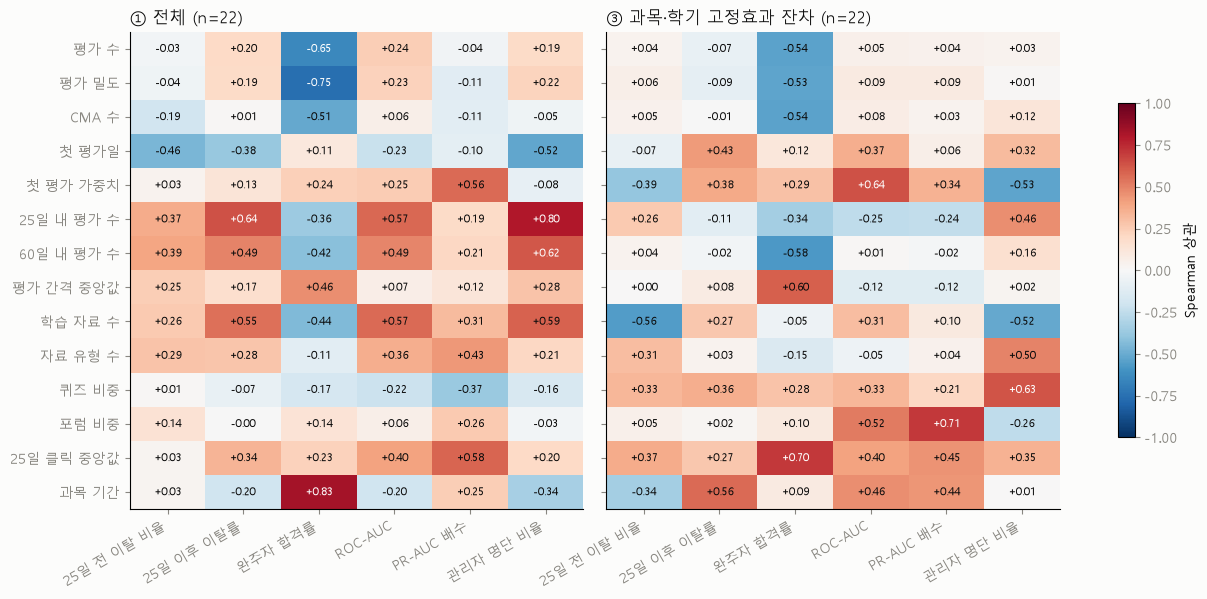

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2), gridspec_kw={'wspace': 0.05})
rows_ = DESIGN
for k, (ax, (name, lv)) in enumerate(zip(axes, [('① 전체 (n=22)', lv_all), ('③ 과목·학기 고정효과 잔차 (n=22)', lv_fe)])):
    mat = lv.reindex(index=rows_, columns=OUTCOME).to_numpy(dtype=float)
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(OUTCOME)), OUTCOME, rotation=30, ha='right')
    ax.set_yticks(range(len(rows_)), rows_ if k == 0 else [''] * len(rows_))
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f'{mat[i, j]:+.2f}', ha='center', va='center', fontsize=8, color='white' if abs(mat[i, j]) > 0.6 else INK)
    ax.set_title(name, loc='left')
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.7, label='Spearman 상관')
plt.show()

**해석 — 통제 후에도 남는 관계는 성취·조기 탐지·운영에 모이고, 재학 유지에는 없다**

판정 분포: 일관 11 / 부분 4 / 과목 간 차이만 18 / 과목 내 변화만 22 / 상충 9 / 약함 20 (설계 14개 × 결과 6개 = 84쌍)

| 목적 | 일관된 관계 (① 전체 / ② 과목 내 / ③ 고정효과 / ④ 과목 평균) | 읽는 법 |
|---|---|---|
| B. 학업 성취 | 평가 수 × 합격률 −0.65 / −0.58 / −0.54 / −0.57 | 평가가 많을수록 완주자 합격률이 낮다 |
| | 평가 밀도 × 합격률 −0.75 / −0.81 / −0.53 / −0.57 | |
| | CMA 수 × 합격률 −0.51 / −0.58 / −0.54 / −0.49 | |
| | 평가 간격 중앙값 × 합격률 +0.46 / +0.57 / +0.60 / +0.56 | 평가 간격이 넓을수록 합격률이 높다 |
| C. 조기 탐지 | 25일 클릭 중앙값 × PR-AUC 배수 +0.58 / +0.60 / +0.45 / +0.86 | 초기 참여가 많은 과목에서 위험 학생이 잘 구분된다 |
| | 25일 클릭 중앙값 × ROC-AUC +0.40 / +0.70 / +0.40 / +0.43 | |
| | 첫 평가 가중치 × PR-AUC 배수 +0.56 / +0.22 / +0.34 / +0.93 | 첫 평가에 점수 의미가 있을수록 잘 구분된다 |
| | 학습 자료 수 × ROC-AUC +0.57 / +0.16 / +0.31 / +0.50 | 약한 수준 |
| D. 관리자 운영 | 25일 내 평가 수 × 명단 비율 +0.80 / +0.53 / +0.46 / +0.80 | 초기 평가가 있으면 명단이 커진다 |

- **첫 평가 가중치 × ROC-AUC는 고정효과 수준에서 +0.64**(과목 내 변화만)이고, 명단 비율과는 −0.53이다. 가중치를 낮춘 학기에 성능이 떨어지고 명단이 커지는지 5절 사례로 확인한다.
- **A. 재학 유지에는 일관된 설계 관계가 없다.** "25일 내 평가 수 × 25일 이후 이탈률"은 전체 +0.64지만 고정효과 −0.11로 **과목 간 차이만**이다. 초기 평가가 없는 EEE·GGG가 원래 이탈률이 낮은 과목이라 생긴 관계이며, 초기 평가가 이탈을 늘린다는 뜻이 아니다. 과목 간 차이만인 관계 18개는 모두 이런 교란 가능성 때문에 설계 근거로 쓰지 않는다.
- **과목 기간 × 합격률(부분, +0.83 / +0.79 / +0.09 / +0.94)**은 고정효과에서 사라진다. 3절에서 본 개강 시기(B·J) 효과이며 설계 근거가 아니다.

## 5. 같은 과목에서 설계만 바뀐 학기 — 이중차분

**왜 보는가**: 상관은 과목·학생 구성이 섞이지만, **같은 과목에서 설계만 바뀐 학기**는 과목 자체가 통제된다.
다만 학기마다 전체적인 변화(예: 2014년에 모든 과목의 초기 이탈이 늘어남)가 있으므로, **같은 기간 다른 과목의 평균 변화를 빼서**(이중차분) 설계 변화의 몫을 추정한다.

| 사례 | 비교 | 바뀐 설계 | 대조 과목 |
|---|---|---|---|
| S1 BBB | 2013J → 2014J | CMA 5개 삭제(평가 11 → 5), 첫 평가 가중치 5 → 0 | 같은 기간 두 학기가 있는 AAA·DDD·EEE·FFF·GGG |
| S2 DDD | 2013J → 2014J | 첫 평가일 25 → 20일, 첫 평가 가중치 10 → 5 | AAA·BBB·EEE·FFF·GGG |
| S3 FFF | 2013J → 2014J | 첫 평가일 19 → 24일 | AAA·BBB·DDD·EEE·GGG |
| S4 FFF | 2013B → 2014B | 첫 평가일 19 → 24일 | BBB·DDD |
| S5 DDD | 2014B → 2013B | CMA 7개(가중치 25)와 25일 내 평가 2개가 있는 학기 | BBB·FFF |

사례마다 표본은 한 쌍이므로 **방향이 여러 사례에서 반복되는지**만 근거로 쓴다.

In [6]:
CASES = [
    ('S1 BBB CMA 삭제·첫 평가 가중치 0', 'BBB', '2013J', '2014J', ['AAA', 'DDD', 'EEE', 'FFF', 'GGG']),
    ('S2 DDD 첫 평가 25→20일', 'DDD', '2013J', '2014J', ['AAA', 'BBB', 'EEE', 'FFF', 'GGG']),
    ('S3 FFF 첫 평가 19→24일 (J)', 'FFF', '2013J', '2014J', ['AAA', 'BBB', 'DDD', 'EEE', 'GGG']),
    ('S4 FFF 첫 평가 19→24일 (B)', 'FFF', '2013B', '2014B', ['BBB', 'DDD']),
    ('S5 DDD CMA 7개·25일 내 평가 2개', 'DDD', '2014B', '2013B', ['BBB', 'FFF']),
]
DID_OUT = ['25일 전 이탈 비율', '25일 이후 이탈률', '완주자 합격률', 'ROC-AUC', 'PR-AUC 배수', '관리자 명단 비율']
Ti = T.set_index(MP)
did_rows = []
for name, m, pre, post, ctrl in CASES:
    for out in DID_OUT:
        change = Ti.loc[(m, post), out] - Ti.loc[(m, pre), out]
        ctrl_change = np.mean([Ti.loc[(c, post), out] - Ti.loc[(c, pre), out] for c in ctrl])
        did_rows.append({'사례': name, '결과 지표': out, '이전': Ti.loc[(m, pre), out], '이후': Ti.loc[(m, post), out],
                         '과목 변화': change, '대조 과목 평균 변화': ctrl_change, '이중차분': change - ctrl_change})
did = pd.DataFrame(did_rows)
pivot = did.pivot(index='사례', columns='결과 지표', values='이중차분')[DID_OUT].reindex([c[0] for c in CASES])
fmt_pp = {c: '{:+.1%}' for c in DID_OUT if c not in ('ROC-AUC', 'PR-AUC 배수')} | {'ROC-AUC': '{:+.3f}', 'PR-AUC 배수': '{:+.2f}'}
print('이중차분 (설계가 바뀐 과목의 변화 − 같은 기간 대조 과목의 평균 변화)')
show(pivot, fmt_pp)
detail = did[did['사례'].str.startswith('S1')].set_index('결과 지표')[['이전', '이후', '과목 변화', '대조 과목 평균 변화', '이중차분']]
print('S1 상세')
display(detail.round(3))

이중차분 (설계가 바뀐 과목의 변화 − 같은 기간 대조 과목의 평균 변화)


결과 지표,25일 전 이탈 비율,25일 이후 이탈률,완주자 합격률,ROC-AUC,PR-AUC 배수,관리자 명단 비율
사례,,,,,,
S1 BBB CMA 삭제·첫 평가 가중치 0,+0.6%,-1.3%,+4.6%,-0.090,-0.58,+18.9%
S2 DDD 첫 평가 25→20일,+0.4%,-5.6%,-1.1%,-0.057,+0.13,-7.1%
S3 FFF 첫 평가 19→24일 (J),+5.7%,-2.6%,+2.8%,+0.053,+0.44,-4.1%
S4 FFF 첫 평가 19→24일 (B),-2.5%,+3.4%,-5.7%,+0.011,-0.23,+16.3%
S5 DDD CMA 7개·25일 내 평가 2개,+1.8%,-6.3%,-6.8%,-0.063,-0.42,+18.2%


S1 상세


,이전,이후,과목 변화,대조 과목 평균 변화,이중차분
결과 지표,,,,,
25일 전 이탈 비율,0.179,0.219,0.040,0.035,0.006
25일 이후 이탈률,0.134,0.132,-0.002,0.011,-0.013
완주자 합격률,0.673,0.747,0.074,0.027,0.046
ROC-AUC,0.656,0.586,-0.070,0.020,-0.090
PR-AUC 배수,1.872,1.275,-0.597,-0.020,-0.578
관리자 명단 비율,0.274,0.457,0.183,-0.007,0.189


**해석 — 사례에서 반복되는 방향은 세 가지다**

| 사례 | 25일 이후 이탈률 | 완주자 합격률 | ROC-AUC | PR-AUC 배수 | 관리자 명단 비율 |
|---|---:|---:|---:|---:|---:|
| S1 BBB CMA 삭제·첫 평가 가중치 5 → 0 | −1.3%p | **+4.6%p** | **−0.090** | **−0.58** | **+18.9%p** |
| S2 DDD 첫 평가 25 → 20일, 가중치 10 → 5 | −5.6%p | −1.1%p | **−0.057** | +0.13 | −7.1%p |
| S3 FFF 첫 평가 19 → 24일 (J) | −2.6%p | +2.8%p | +0.053 | +0.44 | −4.1%p |
| S4 FFF 첫 평가 19 → 24일 (B) | +3.4%p | −5.7%p | +0.011 | −0.23 | +16.3%p |
| S5 DDD CMA 7개·첫 평가 가중치 2 (2014B 대비) | −6.3%p | **−6.8%p** | **−0.063** | −0.42 | **+18.2%p** |

1. **평가를 줄이면 합격률이 오르고, 늘리면 내려간다**: S1(평가 11 → 5개) +4.6%p, S5(CMA 7개 추가) −6.8%p. 4절의 일관된 관계와 같은 방향이다.
   S1에서 25일 전·후 이탈은 거의 변하지 않아(+0.6%p, −1.3%p), **약한 학생이 먼저 떠나서 합격률이 오른 것(생존자 효과)은 아니다.**
2. **첫 평가 가중치를 낮춘 세 사례(S1·S2·S5) 모두 ROC-AUC가 떨어졌다**(−0.090, −0.057, −0.063). 가중치가 그대로인 FFF 두 사례는 방향이 엇갈린다. S1·S5는 명단도 18%p 이상 커졌다(과대 표시).
3. **첫 평가일을 늦춘 FFF는 J·B 학기 결과가 반대다**: 25일 이후 이탈 −2.6%p vs +3.4%p, 합격률 +2.8%p vs −5.7%p. 첫 평가 시점이 5일 달라지는 정도로는 판단할 수 없다.

- **25일 이후 이탈률은 사례마다 방향이 다르다**(−6.3%p ~ +3.4%p). DDD의 두 사례(초기 평가를 당기거나 늘림)에서 줄었지만 FFF·BBB와 일관되지 않아, **재학 유지 효과는 근거가 약하다.**
- 각 사례는 한 쌍의 학기 비교이고 대조 과목도 2–5개뿐이라, 수치 크기보다 **방향의 반복**만 근거로 쓴다.

## 6. 핵심 관계 시각화

4·5절에서 반복된 관계를 과목별 색으로 본다. **같은 색 점끼리의 차이가 과목 안에서 설계가 바뀐 학기의 차이**다.

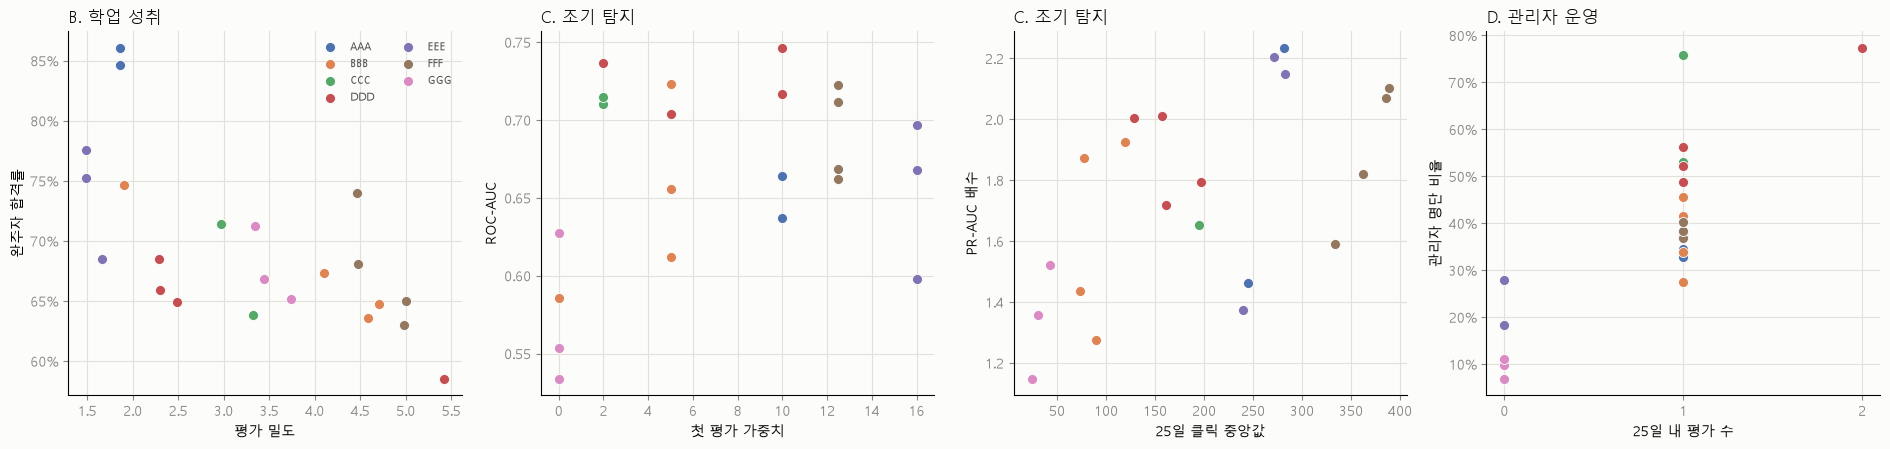

In [7]:
PAIRS = [('평가 밀도', '완주자 합격률', 'B. 학업 성취'), ('첫 평가 가중치', 'ROC-AUC', 'C. 조기 탐지'),
         ('25일 클릭 중앙값', 'PR-AUC 배수', 'C. 조기 탐지'), ('25일 내 평가 수', '관리자 명단 비율', 'D. 관리자 운영')]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))
for ax, (xc, yc, purpose) in zip(axes, PAIRS):
    for m, s in T.groupby('code_module'):
        ax.scatter(s[xc], s[yc], color=MODULE_COLORS[m], s=52, label=m, zorder=3, edgecolor='white', linewidth=0.6)
    ax.set(xlabel=xc, ylabel=yc)
    ax.set_title(purpose, loc='left')
    if xc == '25일 내 평가 수':
        ax.set_xticks([0, 1, 2])
    if yc in ('완주자 합격률', '관리자 명단 비율'):
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[0].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

**해석 — 그림으로 본 핵심 관계**

- **B. 학업 성취**: 평가 밀도가 낮은 AAA(1.9)·EEE(1.5)의 합격률이 높고, 밀도가 가장 높은 DDD 2013B(5.4)가 58.6%로 가장 낮다. 같은 BBB 안에서도 밀도가 4.1 → 1.9로 낮아진 2014J가 가장 높다(74.7%).
- **C. 조기 탐지 (첫 평가 가중치)**: 가중치 0인 GGG·BBB 2014J의 ROC-AUC가 0.53–0.63으로 가장 낮다. 다만 CCC(가중치 2)는 0.71로 높아, 가중치가 유일한 요인은 아니다.
- **C. 조기 탐지 (25일 클릭)**: 초기 클릭이 가장 적은 GGG(24–43회)와 BBB(73–119회)의 PR-AUC 배수가 낮고, EEE·FFF·AAA처럼 초기 참여가 많은 과목이 대체로 높다. 같은 과목 안에서도 클릭이 많은 학기가 높다.
- **D. 관리자 운영**: 25일 내 평가가 없는 EEE·GGG의 명단 비율은 7–28%이고, 평가가 있는 과목은 27–77%다. 평가가 2개인 DDD 2013B가 77.4%로 가장 크다.

## 7. 분야별 비교 — 사회과학 vs STEM

과목 설계보다 **분야**가 결과를 더 크게 가를 수 있다. 제안을 분야별로 달리해야 하는지 확인한다.

In [8]:
dom = T.groupby('분야').agg(과목학기=('code_module', 'size'), **{c: (c, 'mean') for c in ['평가 수', '첫 평가일', '25일 내 평가 수', '25일 클릭 중앙값', '학점 중앙값'] + OUTCOME})
show(dom, {'평가 수': '{:.1f}', '첫 평가일': '{:.0f}', '25일 내 평가 수': '{:.2f}', '25일 클릭 중앙값': '{:.0f}', '학점 중앙값': '{:.0f}', 'ROC-AUC': '{:.3f}', 'PR-AUC 배수': '{:.2f}',
           **{c: '{:.1%}' for c in ['25일 전 이탈 비율', '25일 이후 이탈률', '완주자 합격률', '관리자 명단 비율']}})
mod = T.groupby('code_module').agg(분야=('분야', 'first'), 첫_평가일=('첫 평가일', 'mean'), 첫_평가_가중치=('첫 평가 가중치', 'mean'), 평가_수=('평가 수', 'mean'),
                                   클릭25=('25일 클릭 중앙값', 'mean'), **{c: (c, 'mean') for c in OUTCOME})
print('과목별 평균 (학기 평균)')
show(mod, {'첫_평가일': '{:.0f}', '첫_평가_가중치': '{:.1f}', '평가_수': '{:.1f}', '클릭25': '{:.0f}', 'ROC-AUC': '{:.3f}', 'PR-AUC 배수': '{:.2f}',
           **{c: '{:.1%}' for c in ['25일 전 이탈 비율', '25일 이후 이탈률', '완주자 합격률', '관리자 명단 비율']}})

,과목학기,평가 수,첫 평가일,25일 내 평가 수,25일 클릭 중앙값,학점 중앙값,25일 전 이탈 비율,25일 이후 이탈률,완주자 합격률,ROC-AUC,PR-AUC 배수,관리자 명단 비율
분야,,,,,,,,,,,,
STEM,13,8.2,24,0.85,254,60,14.6%,21.4%,68.1%,0.697,1.87,44.7%
사회과학,9,8.3,32,0.67,109,50,9.9%,12.4%,71.6%,0.621,1.58,27.1%


과목별 평균 (학기 평균)


,분야,첫_평가일,첫_평가_가중치,평가_수,클릭25,25일 전 이탈 비율,25일 이후 이탈률,완주자 합격률,ROC-AUC,PR-AUC 배수,관리자 명단 비율
code_module,,,,,,,,,,,
AAA,사회과학,19,10.0,5.0,263,3.9%,13.5%,85.3%,0.650,1.85,33.7%
BBB,사회과학,17,3.8,9.5,90,17.5%,15.0%,67.6%,0.644,1.63,37.1%
CCC,STEM,18,2.0,8.0,196,20.0%,30.5%,67.7%,0.713,1.72,64.4%
DDD,STEM,23,6.8,7.8,161,14.6%,24.9%,64.5%,0.726,1.88,58.6%
EEE,STEM,33,16.0,4.0,265,12.7%,13.5%,73.8%,0.654,1.91,21.5%
FFF,STEM,22,12.5,12.0,368,13.5%,19.3%,67.5%,0.691,1.90,38.3%
GGG,사회과학,61,0.0,9.0,33,3.8%,8.3%,67.8%,0.572,1.34,9.3%


**해석 — 분야 차이는 크지만, 분야 안에서도 과목 설계가 다르다**

| 지표 | STEM (13) | 사회과학 (9) |
|---|---:|---:|
| 25일 이후 이탈률 | 21.4% | 12.4% |
| 25일 전 이탈 비율 | 14.6% | 9.9% |
| 완주자 합격률 | 68.1% | 71.6% |
| ROC-AUC | 0.697 | 0.621 |
| 관리자 명단 비율 | 44.7% | 27.1% |

- **STEM 과목의 이탈률이 사회과학보다 약 1.7배 높다.** 이탈률 차이의 상당 부분은 설계가 아니라 분야·과목 성격이다. 재학 유지 목적의 설계 제안이 약한 근거밖에 없는 이유다.
- **사회과학의 조기 탐지가 낮은 것은 주로 GGG 영향이다**: GGG 0.572, AAA 0.650, BBB 0.644. 분야보다 **초기 평가·참여 설계**에 따라 갈린다.
- 과목별로 보면 **AAA는 평가가 5개로 적고 합격률이 85.3%로 가장 높다**(표본 약 370명, 해석 주의). EEE는 첫 평가가 33일이지만 초기 클릭이 많아(265회) 조기 탐지가 AAA·BBB와 비슷하다(0.654).

## 8. 결과 저장

| 파일 | 내용 |
|---|---|
| `course_design_indicators_n25.csv` | 과목×학기 22개의 설계 지표와 목적별 결과 지표 |
| `course_design_evidence_n25.csv` | 설계 지표 × 결과 지표의 네 수준 상관과 판정 |
| `course_design_did_n25.csv` | 설계 변경 사례 5건의 이중차분 |

In [9]:
T.to_csv(MODEL_DIR / 'course_design_indicators_n25.csv', index=False, encoding='utf-8-sig')
evidence.to_csv(MODEL_DIR / 'course_design_evidence_n25.csv', index=False, encoding='utf-8-sig')
did.to_csv(MODEL_DIR / 'course_design_did_n25.csv', index=False, encoding='utf-8-sig')
chk = pd.read_csv(MODEL_DIR / 'course_design_indicators_n25.csv')
assert len(chk) == 22 and not chk.duplicated(MP).any()
print('saved', len(chk), len(evidence), len(did))

saved 22 84 30


## 9. 목적별 과목 설계 제안

### 근거 강도 기준

| 강도 | 기준 |
|---|---|
| **강** | 4절 "일관" 또는 통제 수준에서 뚜렷함 + 5절 사례 2건 이상 같은 방향 + 01–06 모델 분석과 일치 |
| **중** | 4절 "일관"이지만 사례가 부족하거나, 해석에 대안 설명이 남음 |
| **약** | 부분 관계이거나 사례 방향이 엇갈림 |
| **근거 없음** | 과목 간 차이만이거나 개강 시기 효과 |

### 목적별 제안

| 목적 | 제안 | 근거 | 강도 | 주의·반대 효과 |
|---|---|---|---|---|
| **C. 조기 탐지** | **첫 평가(3–4주 안)에 성적 가중치를 둔다** (연습용 가중치 0 평가만 두지 않음) | 가중치 × PR-AUC 배수 일관, × ROC-AUC 고정효과 +0.64. 가중치를 낮춘 3개 사례 모두 ROC-AUC 하락(−0.06 ~ −0.09). BBB 2014J 과대 표시(03 노트북) | **강** | 초기 평가가 생기면 관리자 명단이 커진다(D) |
| | **개강 후 3–4주에 참여를 유도하는 학습 활동을 설계한다** (주차별 활동·포럼) | 25일 클릭 × PR-AUC 배수·ROC-AUC 일관. 평가가 늦은 EEE는 접속이 1위 신호(02 노트북) | 중 | 클릭은 설계 결과이지 직접 설계 변수가 아님 |
| | 25일 안에 평가가 없는 과목(GGG)에 **조기 체크포인트를 둔다** | GGG 조기 탐지 최저(ROC 0.53–0.63), 02 노트북에서 어떤 신호도 약함 | 중 | 과목 간 비교 근거뿐(과목 내 변화 사례 없음) |
| **B. 학업 성취** | **작은 평가를 촘촘히 늘리기보다, 간격을 둔 핵심 평가 중심으로 구성한다** | 평가 수·밀도·CMA 수 × 합격률 일관(−0.5 ~ −0.8), 간격 × 합격률 +0.46 ~ +0.60. S1 +4.6%p, S5 −6.8%p | 중 | 평가 구성이 바뀌면 **성적 산출 방식 자체가 달라져** 합격률이 기계적으로 변했을 수 있음. 학습 효과인지 채점 효과인지 구분 불가 |
| **A. 재학 유지** | 설계만으로 이탈을 줄인다는 제안은 하지 않는다. **초기 저부담 평가 시점 조정을 실험 후보**로 둔다 | 4절 일관 관계 없음(과목 간 차이만). 사례 방향 혼재(−6.3%p ~ +3.4%p). 이탈률 차이는 분야(STEM 1.7배)·과목 성격이 큼 | 약 / 근거 없음 | 효과를 알려면 학기 단위 단계 도입이나 무작위 비교가 필요 |
| **D. 관리자 운영** | **초기 평가를 도입·추가할 때 관리자 인력 계획을 함께 세운다** | 25일 내 평가 수 × 명단 비율 일관(+0.46 ~ +0.80). S1·S5에서 명단 +18%p | 강 | 명단 증가는 조기 탐지 향상의 대가(C와 교환 관계) |
| **E. 재학습 안정성** | **학기 간 평가 일정·가중치를 유지하고, 바꿀 때는 배포 전에 모델 성능을 점검한다** | S1 설계 변경 후 PR-AUC 배수 −0.58로 가장 크게 하락. BBB 2014J holdout 과대 표시(01·03 노트북) | 강 | 개편 자체를 막자는 뜻이 아님. 변경을 알려주면 보정·재학습으로 대응 가능 |
| (제안 안 함) | 과목 기간 조정 | 합격률과의 관계는 개강 시기(B·J) 효과 | 근거 없음 | |

### 설계 요소 × 목적 교환 관계

| 설계 요소 | A. 재학 유지 | B. 학업 성취 | C. 조기 탐지 | D. 관리자 운영 | E. 안정성 |
|---|---|---|---|---|---|
| 첫 평가에 가중치 부여 | ? | ? | **+** | − (명단 증가) | + (0 가중치 과대 표시 방지) |
| 3–4주 안 평가 도입 | ? | − (평가 과밀 시) | **+** | **−** (명단 증가) | 0 |
| 평가 수 줄이기·간격 넓히기 | 0 | **+** | 0 (탐지 저하 근거 없음) | 0 | − (변경 시 점검 필요) |
| 초기 참여 활동 설계 | ? | ? | **+** | 0 | 0 |
| 학기 간 일정 유지 | 0 | 0 | + | + | **+** |

`+` 유리 / `−` 불리 / `0` 근거상 영향 없음 / `?` 근거 부족

- **가장 먼저 권할 조합**: 3–4주 안에 **가중치가 있는 핵심 평가 1개**를 두고, 전체 평가는 **간격을 둔 소수 핵심 평가**로 구성하며, 학기 간 일정은 유지한다. 조기 탐지(C)·성취(B)·안정성(E)에 모두 유리하고, 명단 증가(D)만 인력 계획으로 흡수하면 된다.

### 과목별 적용 예

| 과목 | 현재 설계와 결과 | 우선 제안 | 목적 |
|---|---|---|---|
| GGG | 첫 평가 61일·가중치 0, 25일 클릭 24–43회, ROC 0.572, 이탈률은 낮지만 학기마다 상승(4.0 → 8.1 → 12.9%) | 3–4주 안 가중치 있는 첫 평가, 초기 참여 활동 | C·E |
| BBB | 2014J에 첫 평가 가중치 0·CMA 삭제 → 합격률 +4.6%p, ROC −0.090, 명단 +18.9%p | 첫 평가 가중치 복원, 평가 수는 줄인 구조 유지 | C·B·E |
| EEE | 첫 평가 33일, 평가 4개, 합격률 73.8%, 초기 클릭 많음 | 첫 평가를 3–4주로 당기는 것을 검토(명단 증가 대비) | C·D |
| DDD | 조기 탐지 최고(ROC 0.726), 이탈률 24.9%, CMA 7개였던 2013B 합격률 58.6% | 평가 과밀 피하기, 관리자 인력 우선 배치 | B·D |
| CCC | 이탈률 30.5% 최고, 명단 64.4%, 탐지 양호(0.713), 시험 2회 | 탐지보다 대응 역량·과목 구조 검토(학기 2개뿐, 해석 주의) | D·A |
| FFF | 평가 12개, 초기 클릭 최다(368회), 첫 평가일 변경 결과는 학기마다 반대 | 평가 밀도 조정 검토, 첫 평가일은 현행 유지 | B·E |
| AAA | 평가 5개·합격률 85.3%, 표본 약 370명 | 참고 사례(적은 평가·넓은 간격), 확대 해석 금지 | B |

## 10. 결론

### 핵심 발견

1. **과목 설계와 가장 확실하게 연결되는 목적은 "조기 탐지"와 "운영 안정성"이다.** 첫 평가에 가중치가 있고 초기 참여가 많은 과목·학기일수록 25일 시점에 위험 학생이 잘 구분된다. 첫 평가 가중치를 낮춘 세 사례 모두 탐지 성능이 떨어졌다.
2. **평가를 촘촘히 늘릴수록 완주자 합격률이 낮다.** 네 수준 모두 같은 방향이고 두 사례(평가 삭제 +4.6%p, 추가 −6.8%p)도 일치한다. 다만 성적 산출 방식 변화의 영향과 구분할 수 없다.
3. **과목 설계로 이탈률을 줄인다는 근거는 이 데이터에서 찾지 못했다.** 이탈률 차이는 분야·과목 성격이 크고(STEM 21.4% vs 사회과학 12.4%), 설계와의 상관은 과목·학기를 통제하면 사라진다.
4. **목적 간 교환 관계가 있다.** 초기 평가는 조기 탐지를 높이지만 관리자 명단을 키운다.

### 분석 활용 방법

- 기관의 목적이 **조기 경고 체계 운영**이면 "첫 평가 가중치 + 초기 참여 설계 + 일정 유지"를 권한다(근거 강).
- 목적이 **학업 성취**면 "간격을 둔 소수 핵심 평가"를 권하되, 성적 산출 방식 변화 여부를 함께 확인한다(근거 중).
- 목적이 **이탈 감소**면 설계 변경을 **단계적으로 도입해 효과를 측정하는 실험**을 먼저 설계한다(현재 근거 약).

### 한계

- 과목 7개·과목×학기 22개의 관찰 자료다. 결과는 인과 효과가 아니라 **설계 가설과 그 근거 강도**다.
- 설계 변경 사례는 5건이고 각각 한 쌍의 학기 비교다. 같은 시기의 다른 변화(교수자, 학생 모집)를 통제하지 못했다.
- 과목 이름·내용·난이도가 공개되지 않아 설계 외 과목 특성을 직접 통제할 수 없다.
- 예측 성능은 개발 학기 OOF와 2014J holdout을 함께 쓴 학기별 값이라 표본이 작은 학기(AAA 약 370명)는 불안정하다.